Load Data
-------------------

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# load dataset dataset_1980_2020.csv
raw_data = pd.read_csv('dataset_1980_2020.csv')
raw_data.rename(columns={"Count": "Year"}, inplace=True)
print(raw_data.head())

   Year State  0 to 11  12 to 17  Male  Female  Unknown Gender  White  Black  \
0  1980    AL        0        18    13       5               0      7     10   
1  1981    AL        0        21    19       1               0     13      8   
2  1982    AL        1        19    15       4               0      5     14   
3  1983    AL        2        20    21       1               0      7     15   
4  1984    AL        0        21    19       2               0      7     13   

   Amer. Indian/Alaskan Native  ...  Stranger  Unknown  Firearm  Knife  \
0                            1  ...         4        0       15      3   
1                            0  ...         5        0       13      8   
2                            0  ...         6        0        7      5   
3                            0  ...         4        0       13      7   
4                            0  ...         5        2       12      3   

   Blunt object  Personal  Other/unknown Weapon  One offender involved  \


Pre processing
-------------------

In [3]:
# give each state a numerical value
encoder = LabelEncoder()
raw_data["State"] = encoder.fit_transform(raw_data["State"])  # Assign numerical values to states


# Define the features (excluding 'Year' and 'Count')
features = raw_data.columns.difference(["Year", "Count"])

# Define target variables (Male and Female)
targets = ["Male", "Female"]

# Define X and y
X = raw_data[features]
y = raw_data[targets]  # Multiple target columns (Male and Female)

# Split the data into training and testing sets (80% training, 20% testing)
train_size = int(len(raw_data) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

# Normalize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)



Training and Evaluation
-------------

Male Model Performance:
MAE: 0.02
MSE: 0.01
R² Score: 1.00


Female Model Performance:
MAE: 0.00
MSE: 0.00
R² Score: 1.00




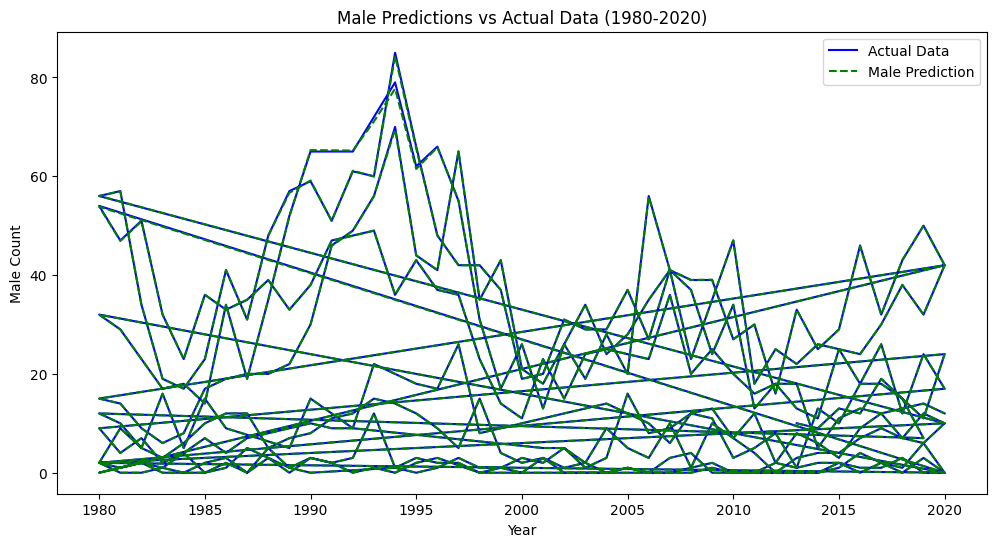

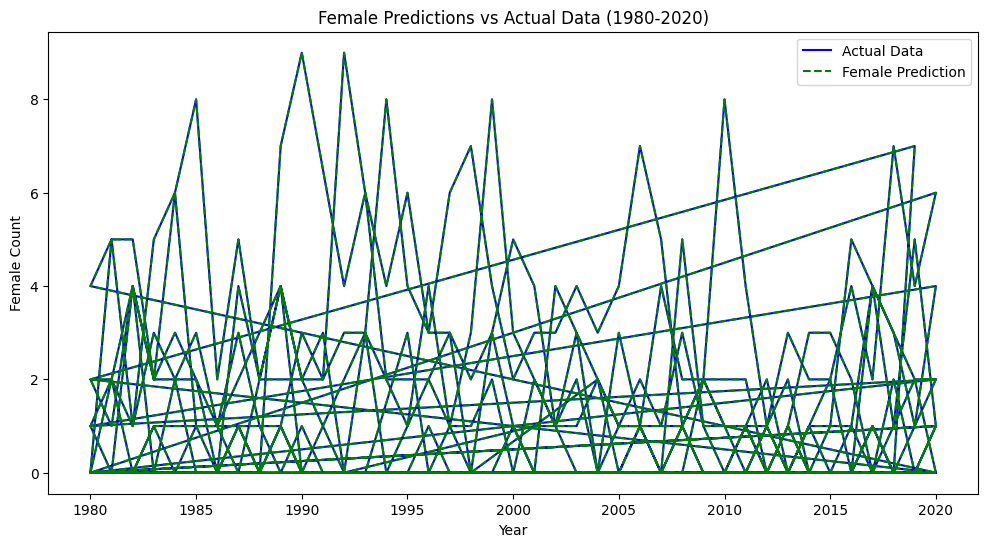

In [ ]:
# Train models for Male and Female
models = {}
for target in targets:
    model = RandomForestRegressor()  # You can choose a different model
    model.fit(X_train, y_train[target])  # Train model for each target
    models[target] = model

# Evaluate models for Male and Female
for target, model in models.items():
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test[target], y_pred)
    mse = mean_squared_error(y_test[target], y_pred)
    r2 = r2_score(y_test[target], y_pred)
    
    print(f"{target} Model Performance:")
    print(f"MAE: {mae:.2f}")
    print(f"MSE: {mse:.2f}")
    print(f"R² Score: {r2:.2f}")
    print("\n")

# Plot predictions for Male and Female
for target, model in models.items():
    y_pred = model.predict(X_test)
    
    plt.figure(figsize=(12, 6))

    # Plot actual data for the years corresponding to the test set
    plt.plot(raw_data['Year'].iloc[train_size:], y_test[target], label="Actual Data", color='blue')  # Actual Data
    
    # Plot the predictions for the current model (only for the years in the test set)
    plt.plot(raw_data['Year'].iloc[train_size:], y_pred, linestyle='dashed', label=f"{target} Prediction", color='red')  # Prediction
    
    plt.xlabel("Year")
    plt.ylabel(f"{target} Count")
    plt.title(f"{target} Predictions vs Actual Data (1980-2020)")
    plt.legend()
    plt.show()



Models


Evaluation of methods
-------------

In [40]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score

# Function for R², MAE, and MSE
def evaluate_model_r2(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f"{name} Performance (Regression Metrics):")
    print(f"MAE: {mae:.2f}")
    print(f"MSE: {mse:.2f}")
    print(f"R² Score: {r2:.2f}")
    
    return y_pred

# Function for accuracy evaluation (classification-like)
def evaluate_model_accuracy(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    
    # For classification-like evaluation, categorize predictions based on a threshold
    threshold = y_test.median()  # Set threshold to the median of the actual values
    y_test_cat = (y_test >= threshold).astype(int)  # 1 if high, 0 if low
    y_pred_cat = (y_pred >= threshold).astype(int)  # 1 if high, 0 if low
    
    # Calculate accuracy
    accuracy = accuracy_score(y_test_cat, y_pred_cat)
    
    print(f"{name} Accuracy (Classification-like): {accuracy * 100:.2f}%\n")
    
    return y_pred

# Store the results separately
results_r2 = {}
results_accuracy = {}

for name, model in trained_models.items():
    # Evaluate regression metrics
    results_r2[name] = evaluate_model_r2(model, X_test, y_test, name)
    
    # Evaluate accuracy metrics
    results_accuracy[name] = evaluate_model_accuracy(model, X_test, y_test, name)


SVM Performance (Regression Metrics):
MAE: 9.00
MSE: 114.40
R² Score: 0.22
SVM Accuracy (Classification-like): 66.58%

Gradient Boosting Performance (Regression Metrics):
MAE: 8.28
MSE: 100.40
R² Score: 0.32
Gradient Boosting Accuracy (Classification-like): 70.89%

Logistic Regression Performance (Regression Metrics):
MAE: 9.41
MSE: 121.65
R² Score: 0.17
Logistic Regression Accuracy (Classification-like): 63.29%

Decision Tree Performance (Regression Metrics):
MAE: 10.19
MSE: 178.25
R² Score: -0.21
Decision Tree Accuracy (Classification-like): 66.08%

Random Forest Performance (Regression Metrics):
MAE: 8.31
MSE: 104.95
R² Score: 0.29
Random Forest Accuracy (Classification-like): 71.14%



PREDICT
-----------

In [46]:
import matplotlib.pyplot as plt

# Assuming you have trained your models and stored them in `trained_models`
# Also assuming `X_test` and `y_test` are prepared correctly from your data

# Choose the feature you want to plot (e.g., 'Male' column)
feature_to_predict = 'Male'

# Ensure you use the years from the test set (`X_test['Year']`)
years_test = X_test['Year']  # 'Year' column from the test set

# Dictionary to store predictions from each model
predictions = {}

# Loop through each model and generate predictions
for name, model in trained_models.items():
    y_pred = model.predict(X_test)  # Generate predictions for the test data
    
    predictions[name] = y_pred

    # Plot actual data (from y_test)
    plt.figure(figsize=(12, 6))
    plt.plot(years_test, y_test[feature_to_predict], label="Actual Data", color='blue')

    # Plot the predictions for the current model
    plt.plot(years_test, y_pred, linestyle='dashed', label=f"{name} Prediction")

    # Add labels and title
    plt.xlabel("Year")
    plt.ylabel(f"{feature_to_predict} Count")
    plt.title(f"{name} Predictions vs Actual Data (1980-2020)")

    # Show the legend
    plt.legend()

    # Display the plot
    plt.show()


KeyError: 'Year'